In [1]:
import pandas as pd
import numpy as np
import io
import json
from fpdf import FPDF
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import matplotlib.dates as md
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as ticker
import plotly.express as px
import plotly.graph_objects as go
import plotly.offline as pyo
from datetime import datetime
from plotly.subplots import make_subplots


In [2]:
import json 

text_file_path = 'me_perf.txt'

# Read the content of the text file and load it into a JSON object
with open(text_file_path, 'r') as file:
    s = json.load(file)  
# Now, you can use the 's' variable to work with your JSON data
s

{'Results_tab': {'table_1': [{'title': 'Ship Name',
    'particulars': 'ANASTASIA'},
   {'title': 'Main Engine Type', 'particulars': '6S60ME-C8'},
   {'title': 'Main Engine Rated Power', 'particulars': '12460KW'},
   {'title': 'Rated RPM', 'particulars': '105'},
   {'title': 'Test Date', 'particulars': '08-Aug-2023'},
   {'title': 'Test Load %', 'particulars': '57.1'},
   {'title': 'New Speed', 'particulars': None},
   {'title': 'New Power', 'particulars': None}],
  'spider_chart': [{'item': 'SFOC Vs Engine Load',
    'type': 'Performance result',
    'value': 2.3},
   {'item': 'ExhTemp Vs Engine Load',
    'type': 'Performance result',
    'value': 29.7},
   {'item': 'T/C Speed Vs Engine Load',
    'type': 'Performance result',
    'value': -0.5},
   {'item': 'Pmax Vs Engine Load',
    'type': 'Performance result',
    'value': -15.3},
   {'item': 'Pcomp Vs Engine Load',
    'type': 'Performance result',
    'value': -12.1},
   {'item': 'Pscav Vs Engine Load',
    'type': 'Performance

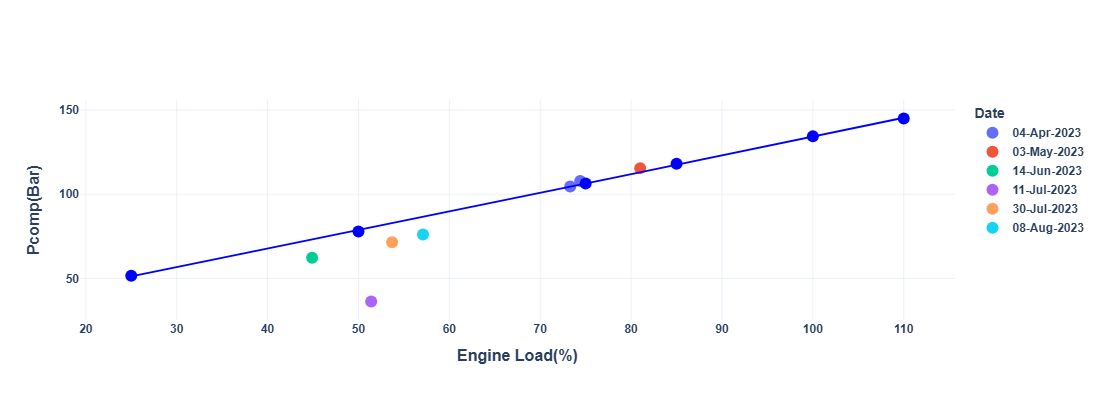

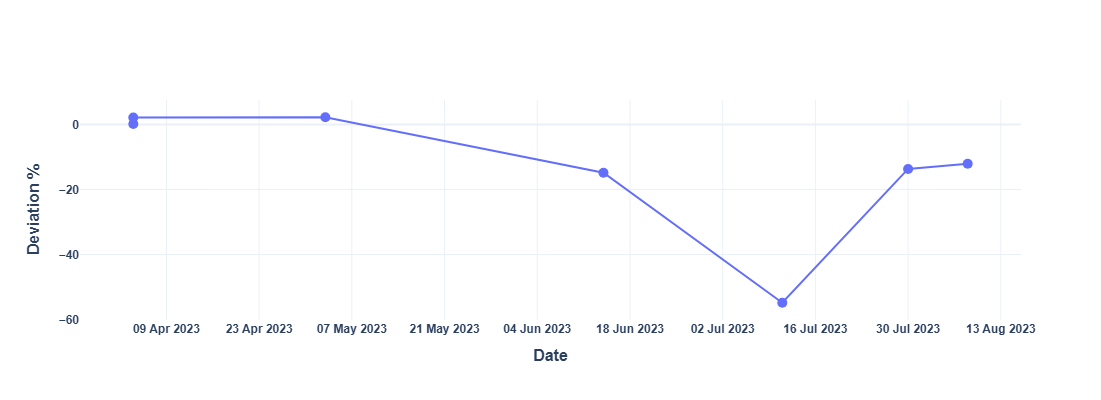

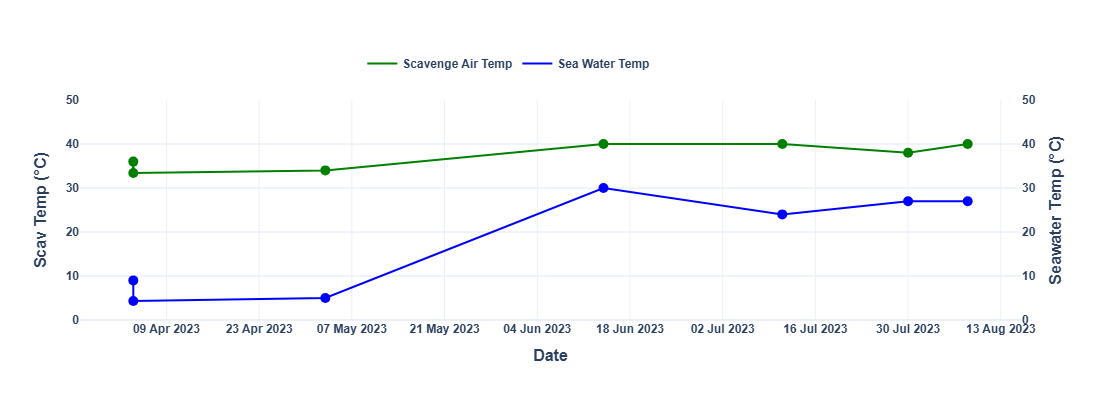

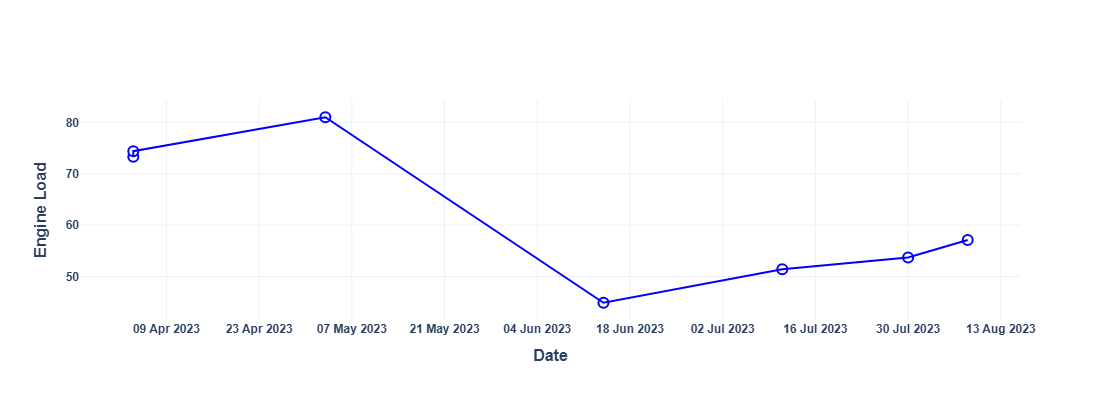

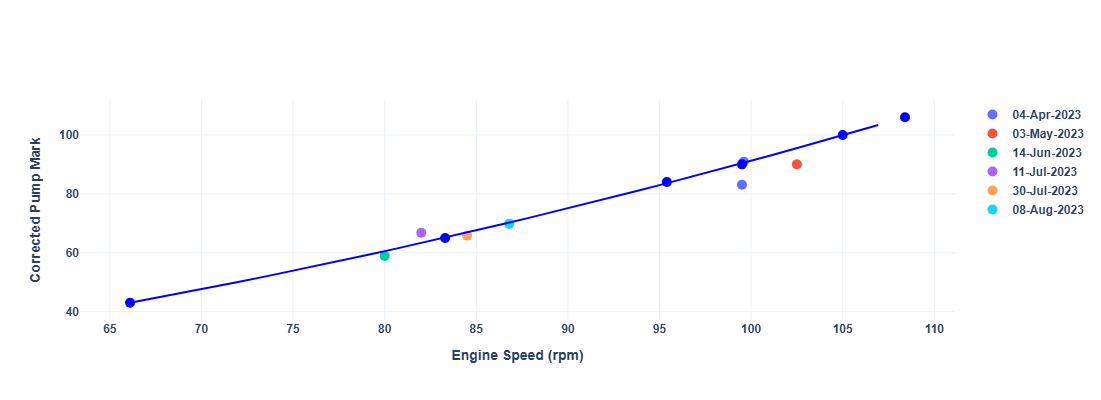

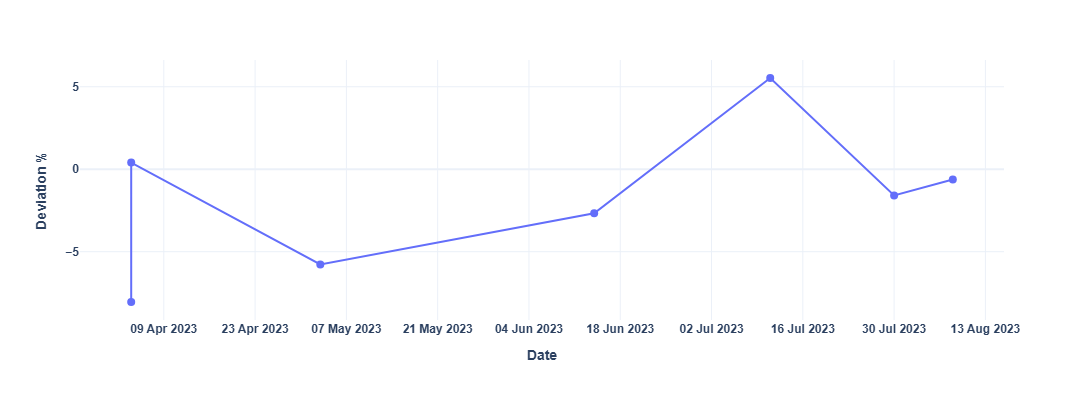

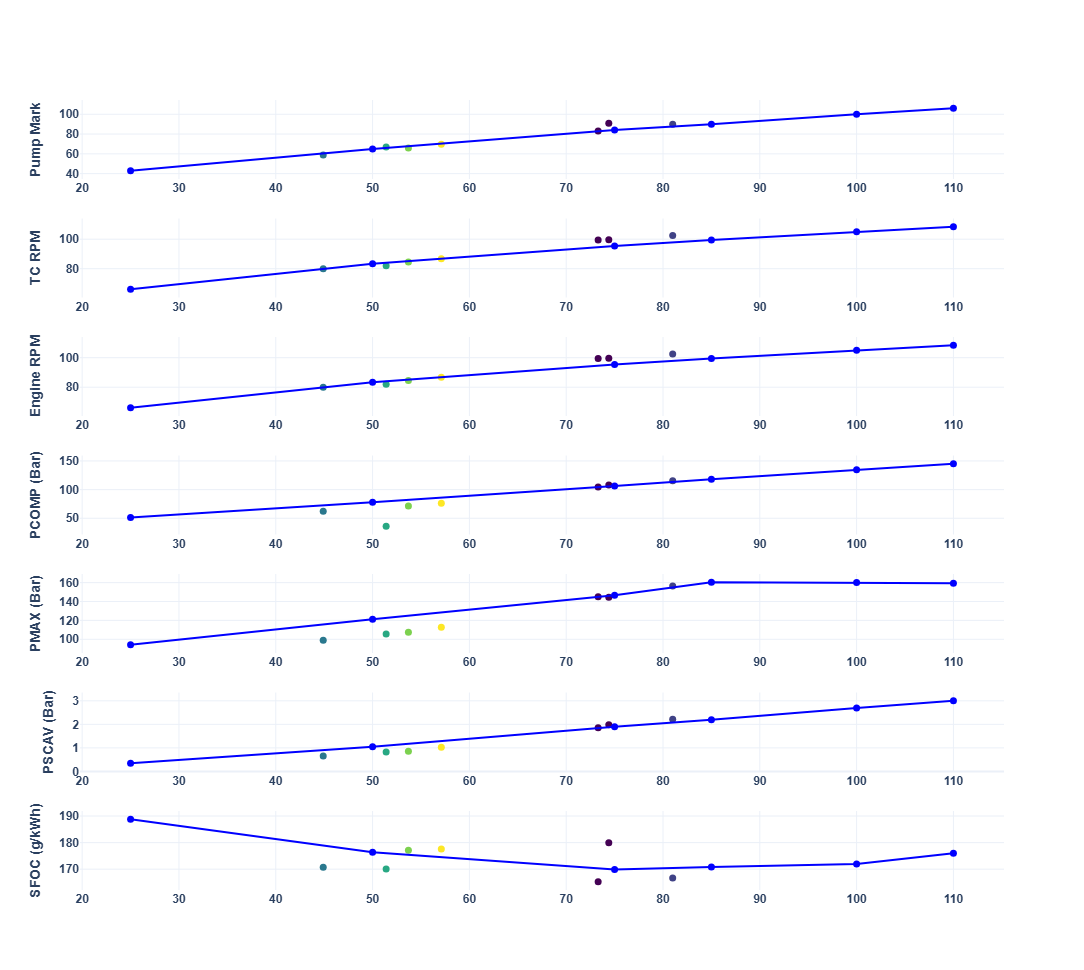

In [200]:
if s['Engine_Performance_Tab']['pcomp_vs_load_chart_1']:
    data47 = pd.DataFrame.from_dict(s['Engine_Performance_Tab']['pcomp_vs_load_chart_1'][0]['scatter_1'])
else:
    data47 = pd.DataFrame()
if not data47.empty:
    data47.rename(columns = {'engine_load':'engine_load scatter'}, inplace = True)
    data47.rename(columns = {'pcomp':'pcomp scatter'}, inplace = True)
else:
    pass
if s['Engine_Performance_Tab']['pcomp_vs_load_chart_1']:
    data48 = pd.DataFrame.from_dict(s['Engine_Performance_Tab']['pcomp_vs_load_chart_1'][0]['scatter_2'])
else:
    data48 = pd.DataFrame()
if not data48.empty:

    data48.rename(columns = {'engine_load':'engine_load curve'}, inplace = True)
    data48.rename(columns = {'pcomp':'pcomp curve'}, inplace = True)
else:
    pass
if s['Engine_Performance_Tab']['pcomp_vs_load_chart_1']:
    load_vs_pcomp = pd.DataFrame.from_dict(s['Engine_Performance_Tab']['pcomp_vs_load_chart_1'][0]['test'])
else:
    load_vs_pcomp = pd.DataFrame()
if not load_vs_pcomp.empty:
    try:
        fig_Load_Pcomp= go.Figure()
        unique_dates = data47['Date'].unique()
        for date in unique_dates:
            filtered_data = data47[data47['Date'] == date]
            
            fig_Load_Pcomp.add_trace(go.Scatter(
                x=filtered_data['engine_load scatter'],
                y=filtered_data['pcomp scatter'],
                mode='markers',
                marker=dict(size=12),
                name=str(date),  
                showlegend=True  
            ))
        
        fig_Load_Pcomp.add_trace(go.Scatter(
            x=data48['engine_load curve'],
            y=data48['pcomp curve'],
            mode='markers',
            marker=dict(symbol='circle', color='blue', size=12),
            showlegend=False
        ))
        
        fig_Load_Pcomp.add_trace(go.Scatter(
            x=load_vs_pcomp['x'],
            y=load_vs_pcomp['y'],
            mode='lines',
            line=dict(color='blue'),
            name='Load vs Pcomp Curve',
            showlegend=False
        ))
        
        fig_Load_Pcomp.update_layout(
            width=800,  
            height=400, 
            xaxis=dict(title='Engine Load(%)', title_font=dict(size=16, weight='bold')),
            yaxis=dict(title='Pcomp(Bar)', title_font=dict(size=16, weight='bold')),
            legend_title='Date',  
            font=dict(family="Arial, sans-serif", weight='bold'),
            template="plotly_white"
        )
        fig_Load_Pcomp.show()
        plot_div = pyo.plot(fig_Load_Pcomp, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})

    except:
        fig = go.Figure()
        fig.add_annotation(
            text="No data available",  
            x=0.8, 
            y=0.8, 
            font=dict(size=20, family="Arial"),  
            align="center",  
            valign="middle", 
        )
        fig.update_layout(
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        plot_bgcolor='white',  
        font=dict(family="Arial, sans-serif", size=20),
        template="plotly_white",  
    )
        
        # Show plot
        fig.show()
        plot_div = pyo.plot(fig, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})

else:
    pass
if s['Engine_Performance_Tab']['pcomp_vs_load_chart_2']:
    data49 = pd.DataFrame.from_dict(s['Engine_Performance_Tab']["pcomp_vs_load_chart_2"])
else:   
    data49 = pd.DataFrame()
if not data49.empty:

    try:
        data49['date'] = data49['date'].astype("datetime64[ns]")
    except:    
        data49['date'] = pd.to_datetime(data49['date'], format='%d-%b-%Y')
    data49 = data49.sort_values(by='date')
    data49['date'] = data49['date'].astype(str)
    try:
        fig_Deviation = go.Figure()

        fig_Deviation.add_trace(go.Scatter(
            x=data49['date'],
            y=data49['deviation'],
            mode='lines+markers',  
            marker=dict(size=10), 
            name='% Deviation'  
        ))
        
        fig_Deviation.update_layout(
            width=800,  
            height=400, 
            xaxis=dict(
                title='Date',
                tickformat='%d %b %Y',
                title_font=dict(size=16, weight='bold')
            ),
            yaxis=dict(
                title='Deviation %',
                title_font=dict(size=16, weight='bold'),
            ),
            legend_title=None,
            font=dict(family="Arial, sans-serif", weight='bold'),
            template="plotly_white"  
        )
        
        fig_Deviation.show()
        plot_div1 = pyo.plot(fig_Deviation, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})

    except:
        fig = go.Figure()
        fig.add_annotation(
            text="No data available",  
            x=0.8,  
            y=0.8, 
            font=dict(size=20, family="Arial"),  
            align="center",  
            valign="middle",  
        )
        fig.update_layout(
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        plot_bgcolor='white',  
        font=dict(family="Arial, sans-serif", size=20),
        template="plotly_white",  
       )
        
        plot_div1 = pyo.plot(fig, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})
        fig.show()
if s['Engine_Performance_Tab']['pcomp_vs_load_table_1']:

    data50 = pd.DataFrame.from_dict(s['Engine_Performance_Tab']['pcomp_vs_load_table_1'])
else:
    data50 = pd.DataFrame()
if not data50.empty:

    data50.rename(columns = {'dates':'Date of measurement'}, inplace = True)
    data50.rename(columns = {'historicx':'Engine Load (%)'}, inplace = True)
    data50.rename(columns = {'historicy':'Pcomp (Bar)'}, inplace = True)
    # data50['Date of measurement'] = data50['Date of measurement'].astype('datetime64[ns]')
    data50['Date of measurement'] = pd.to_datetime(data50['Date of measurement'], format='%d-%b-%Y')

    data50 = data50.astype(str)
else:
    pass
if s['Engine_Performance_Tab']['pcomp_vs_load_table_2']:
    data51 = pd.DataFrame.from_dict(s['Engine_Performance_Tab']['pcomp_vs_load_table_2'])
else:
    data51 = pd.DataFrame()
if not data51.empty:
    data51.rename(columns = {'x':'Engine Load (%)'}, inplace = True)
    data51.rename(columns = {'y':'Pcomp (Bar)'}, inplace = True)
    data51 = data51.dropna()
    data51 = data51.astype(str)
else:
    pass
if s['Engine_Performance_Tab']['scav_temp_vs_date_chart_1']:
    data64 = pd.DataFrame.from_dict(s['Engine_Performance_Tab']['scav_temp_vs_date_chart_1'][0]['scatter_1'])
else:
    data64 = pd.DataFrame()
if not data51.empty:

    try:
        data64['Date'] = data64['Date'].astype("datetime64[ns]")
    except:    
        data64['Date'] = pd.to_datetime(data64['Date'], format='%d-%b-%Y')
    data64 = data64.sort_values(by='Date')
    data64['Date'] = data64['Date'].astype("str")
else:
    pass
if s['Engine_Performance_Tab']['scav_temp_vs_date_chart_1']:
    data65 = pd.DataFrame.from_dict(s['Engine_Performance_Tab']['scav_temp_vs_date_chart_1'][0]['scatter_2'])
else:
    data65 = pd.DataFrame()
if not data65.empty:
    try:
        data65['date'] = data65['date'].astype("datetime64[ns]")
    except:    
        data65['date'] = pd.to_datetime(data65['date'], format='%d-%b-%Y')
    data65 = data65.sort_values(by='date')
    data65['date'] = data65['date'].astype("str")
    data65['sw_temp'] = data65['sw_temp'].astype(float)

    try:
        fig_Scav_date = go.Figure()

        fig_Scav_date.add_trace(go.Scatter(
            x=data64['Date'],
            y=data64['scavenge_air'],
            mode='lines',
            marker=dict(size=10),
            line=dict(color='green'),
            name='Scavenge Air Temp',  
            yaxis='y1' 
        ))

        fig_Scav_date.add_trace(go.Scatter(
            x=data65['date'],
            y=data65['sw_temp'],
            mode='lines',
            line=dict(color='blue'),
            name='Sea Water Temp',
            yaxis='y2'  
        ))

        for unique_date in data65['date'].unique():
            temp_data = data65[data65['date'] == unique_date]  
            fig_Scav_date.add_trace(go.Scatter(
                x=temp_data['date'],
                y=temp_data['sw_temp'],
                mode='markers',
                marker=dict(size=10),
                line=dict(color='blue'),
                name=f'{unique_date}',
                showlegend= False,
                yaxis='y2'  
            ))

        for unique_date in data64['Date'].unique():
            temp_data = data64[data64['Date'] == unique_date] 
            fig_Scav_date.add_trace(go.Scatter(
                x=temp_data['Date'],
                y=temp_data['scavenge_air'],
                mode='markers+lines', 
                marker=dict(size=10),
                line=dict(color='green'),
                showlegend= False,
                yaxis='y1'  
            ))
            
        fig_Scav_date.update_layout(

            xaxis=dict(
                title='Date',
                tickformat='%d %b %Y',
                title_font=dict(size=16, weight='bold')
            ),
            yaxis=dict(
                title='Scav Temp (°C)',
                title_font=dict(size=16, weight='bold'),
                range=[0, 50]
            ),
            yaxis2=dict(
                title='Seawater Temp (°C)',
                title_font=dict(size=16, weight='bold'),
                overlaying='y',
                side='right',
                range=[0, 50]
            ),
            font=dict(family="Arial, sans-serif", weight='bold'),
            template="plotly_white",  
            showlegend=True,
            width=800,  
            height=400, 
            legend=dict(orientation="h",  # Horizontal layout
                x=0.3, 
                y=1.1,  # Position above the plot
                xanchor="left",  # Anchor to the left
                yanchor="bottom",  # Anchor to the bottom
            ),
    
        )

        # Show plot
        fig_Scav_date.show()
        plot_div2 = pyo.plot(fig_Scav_date, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})


    except:
        fig = go.Figure()
        fig.add_annotation(
            text="No data available",  
            x=0.8,  
            y=0.8,  
            font=dict(size=20, family="Arial"), 
            align="center",  
            valign="middle",  
        )
        fig.update_layout(
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        plot_bgcolor='white',  
        font=dict(family="Arial, sans-serif", size=20),
        template="plotly_white",  
    )
        
        fig.show()
        plot_div2 = pyo.plot(fig, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})

else:
    pass
if s['Engine_Performance_Tab']["scav_temp_vs_date_chart_2"]:
        data66 = pd.DataFrame.from_dict(s['Engine_Performance_Tab']["scav_temp_vs_date_chart_2"])
else:
    data66 = pd.DataFrame()
        
if not data66.empty:
    try:
        data66['tdate'] = pd.to_datetime(data66['tdate'])
    except:
        data66['tdate'] = pd.to_datetime(data66['tdate'], format='%d-%b-%Y')

    data66 = data66.sort_values(by='tdate')
    data66['tdate'] = data66['tdate'].astype(str)

    try:
        fig_Engine_Load = go.Figure()
        fig_Engine_Load.add_trace(go.Scatter(
            x=data66['tdate'],
            y=data66['testx'],
            mode='markers',
            marker=dict(
                size=10,
                color='white',  
                line=dict(
                    width=2,  
                    color='blue'  
                )
            ),
            name='Engine Load',
            showlegend=False
        ))
        
        fig_Engine_Load.add_trace(go.Scatter(
            x=data66['tdate'],
            y=data66['testx'],
            mode='lines',
            line=dict(color='blue'),
            name='Engine Load Line',
            showlegend=False
        ))
        # Update layout for titles, labels, and styling
        fig_Engine_Load.update_layout(
            width=800,  
            height=400, 
            xaxis=dict(
                title='Date',
                tickformat='%d %b %Y',                
                title_font=dict(size=16, family='Arial', weight='bold'),
            ),
            yaxis=dict(
                title='Engine Load',
                title_font=dict(size=16, family='Arial', weight='bold'),
            ),
            legend=dict(
                title=None,
                x=0.8,
                y=1.0,
                bgcolor="rgba(255, 255, 255, 0.5)",
                bordercolor="black",
                borderwidth=1
            ),
            font=dict(family="Arial, sans-serif", weight='bold'),
            template="plotly_white",
        )

        fig_Engine_Load.show()
        plot_div3 = pyo.plot(fig_Engine_Load, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})

    except:
        fig = go.Figure()
        fig.add_annotation(
            text="No data available",  
            x=0.8,  
            y=0.8, 
            font=dict(size=20, family="Arial"),  # Font size and family
            align="center",  # Align text in the center
            valign="middle",  # Vertical alignment in the middle
        )
        fig.update_layout(
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        plot_bgcolor='white',  # Set background color to white
        font=dict(family="Arial, sans-serif", size=20),
        template="plotly_white",  # Use white background template
       )
        
        plot_div3 = pyo.plot(fig, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})
        fig.show()

else:
    pass
if s['Engine_Performance_Tab']['scav_temp_vs_date_table_1']:
    data67 = pd.DataFrame.from_dict(s['Engine_Performance_Tab']['scav_temp_vs_date_table_1'])
else:
    data67 = pd.DataFrame()
if not data67.empty:
    data67.rename(columns = {'dates':'Date of measurement'}, inplace = True)
    data67.rename(columns = {'historicx':'Engine Load (%)'}, inplace = True)
    data67.rename(columns = {'historicy':'Scav Temp(degree C)'}, inplace = True)
    data67.rename(columns = {'historicz':'S.W Temp(degree C)'}, inplace = True)
    # data67['Date of measurement'] = data50['Date of measurement'].astype('datetime64[ns]')
    data67['Date of measurement'] = pd.to_datetime(data67['Date of measurement'], format='%d-%b-%Y')

    data67 = data67.astype(str)
else:
    pass


if not s['Engine_Performance_Tab']['pump_mark_vs_ES_chart_1']:
    print("No data available for Pump Mark vs Engine Speed.")
else:
    # Prepare scatter data
    data42 = pd.DataFrame.from_dict(s['Engine_Performance_Tab']['pump_mark_vs_ES_chart_1'][0]['scatter_1'])
    data42.rename(columns={
        'Engine_speed': 'Engine speed scatter',
        'Pump_mark': 'corrected pump mark scatter'
    }, inplace=True)

    # Prepare curve data
    data43 = pd.DataFrame.from_dict(s['Engine_Performance_Tab']['pump_mark_vs_ES_chart_1'][0]['scatter_2'])
    data43.rename(columns={
        'Engine_speed': 'Engine speed curve',
        'Pump_mark': 'corrected pump mark curve'
    }, inplace=True)

    # Prepare line data
    enginespeed_vs_pumpmark = pd.DataFrame.from_dict(s['Engine_Performance_Tab']['pump_mark_vs_ES_chart_1'][0]['test'])

    # Initialize the figure
    fig_engine_pump = go.Figure()

    # Create scatter traces for each unique date
    unique_dates = data42['Date'].unique()
    for date in unique_dates:
        filtered_data = data42[data42['Date'] == date]
        fig_engine_pump.add_trace(go.Scatter(
            x=filtered_data['Engine speed scatter'],
            y=filtered_data['corrected pump mark scatter'],
            mode='markers',
            marker=dict(size=10),
            name=f"{date}"
        ))

    # Add scatter and line traces
    fig_engine_pump.add_trace(go.Scatter(
        x=data43['Engine speed curve'],
        y=data43['corrected pump mark curve'],
        mode='markers',
        marker=dict(size=10, color='blue'),
        showlegend=False
    ))

    fig_engine_pump.add_trace(go.Scatter(
        x=enginespeed_vs_pumpmark['x'],
        y=enginespeed_vs_pumpmark['y'],
        mode='lines',
        line=dict(color='blue'),
        showlegend=False
    ))

    # Update the layout
    fig_engine_pump.update_layout(
        width=800,  
        height=400, 
        xaxis_title="Engine Speed (rpm)",
        yaxis_title="Corrected Pump Mark",
        font=dict(family="Arial, sans-serif", weight='bold'),
        legend_title=None,
        template="plotly_white"
    )

    # Display the figure
    fig_engine_pump.show()
    plot_div4 = pyo.plot(fig_engine_pump, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})

data44 = pd.DataFrame.from_dict(s['Engine_Performance_Tab']["pump_mark_vs_ES_chart_2"])
try:
    data44['date'] = pd.to_datetime(data44['date'], errors='coerce', format='%d-%b-%Y')
    data44 = data44.sort_values(by='date')
    data44['date'] = data44['date'].astype(str)

    fig_deviation_pump = px.line(
        data44,
        x='date',
        y='deviation',
        labels={'date': 'Month', 'deviation': 'Deviation %'},
        markers=True
    )

    fig_deviation_pump.update_traces(marker=dict(size=8))
    fig_deviation_pump.update_layout(
        width=800,  
        height=400, 
        xaxis=dict(
                title='Date',
                tickformat='%d %b %Y',                
            ),
        font=dict(family="Arial, sans-serif", weight='bold'),
        template="plotly_white"
    )
    fig_deviation_pump.show()
    plot_div5 = pyo.plot(fig_deviation_pump, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})

except:
    fig = go.Figure()
    fig.add_annotation(
        text="No data available",  # The text to display
        x=0.8,  # x-position (0.5 centers it)
        y=0.8,  # y-position (0.5 centers it)
        font=dict(size=20, family="Arial"),  # Font size and family
        align="center",  # Align text in the center
        valign="middle",  # Vertical alignment in the middle
    )
    fig.update_layout(
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    plot_bgcolor='white',  # Set background color to white
    font=dict(family="Arial, sans-serif", size=20),
    template="plotly_white",  # Use white background template
   )
    
    plot_div5 = pyo.plot(fig, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})
    fig.show()

if s['Power_curve_Tab']['graph_1']:
    data52 = pd.DataFrame.from_dict(s['Power_curve_Tab']['graph_1'])
else:
    data52 = pd.DataFrame ()  
if s['Power_curve_Tab']['graph_2']:
    data53 = pd.DataFrame.from_dict(s['Power_curve_Tab']['graph_2'])
else:
    data53 = pd.DataFrame()
pcomp_1 =  list(data53["pcomp"])
pmax_1 =  list(data53["pmax"])

if s['Power_curve_Tab']['graph_2']:

    data53 = pd.DataFrame.from_dict(s['Power_curve_Tab']['graph_2'])

else:

    data53 = pd.DataFrame()

pcomp_1 =  list(data53["pcomp"])

pmax_1 =  list(data53["pmax"])

if not data53.empty:
    data53['date'] = pd.to_datetime(data53['date'])
    
    data53['date_category'] = data53['date'].astype('category').cat.codes
    
    fig_Power_Curve = make_subplots(rows=7, cols=1, shared_yaxes=False, vertical_spacing=0.05)

    fig_Power_Curve.add_trace(
        go.Scatter(x=data53['engine_load'], y=data53['pump_mark'], mode='markers',
                   marker=dict(color=data53['date_category'], size=7, colorscale='Viridis'), name='Pump Mark Scatter'),
        row=1, col=1
    )
    fig_Power_Curve.add_trace(
        go.Scatter(x=data52['engine_load1'], y=data52['pump_mark1'], mode='lines+markers',
                   marker=dict(size=7), name='Pump Mark Line', line=dict(color='blue')),
        row=1, col=1
    )
    
    
    fig_Power_Curve.add_trace(
        go.Scatter(x=data53['engine_load'], y=data53['engine_rpm'], mode='markers',
                   marker=dict(color=data53['date_category'], size=7, colorscale='Viridis'), name='TC RPM Scatter'),
        row=2, col=1
    )
    fig_Power_Curve.add_trace(
        go.Scatter(x=data52['engine_load1'], y=data52['engine_rpm1'], mode='lines+markers',
                   marker=dict(size=7), name='TC RPM Line', line=dict(color='blue')),
        row=2, col=1
    )
    
    fig_Power_Curve.add_trace(
        go.Scatter(x=data53['engine_load'], y=data53['engine_rpm'], mode='markers',
                   marker=dict(color=data53['date_category'], size=7, colorscale='Viridis'), name='Engine RPM Scatter'),
        row=3, col=1
    )
    fig_Power_Curve.add_trace(
        go.Scatter(x=data52['engine_load1'], y=data52['engine_rpm1'], mode='lines+markers',
                   marker=dict(size=7), name='Engine RPM Line', line=dict(color='blue')),
        row=3, col=1
    )
    
    fig_Power_Curve.add_trace(
        go.Scatter(x=data53['engine_load'], y=data53['pcomp'], mode='markers',
                   marker=dict(color=data53['date_category'], size=7, colorscale='Viridis'), name='PCOMP Scatter'),
        row=4, col=1
    )
    fig_Power_Curve.add_trace(
        go.Scatter(x=data52['engine_load1'], y=data52['pcomp1'], mode='lines+markers',
                   marker=dict(size=7), name='PCOMP Line', line=dict(color='blue')),
        row=4, col=1
    )
    
    fig_Power_Curve.add_trace(
        go.Scatter(x=data53['engine_load'], y=data53['pmax'], mode='markers',
                   marker=dict(color=data53['date_category'], size=7, colorscale='Viridis'), name='PMAX Scatter'),
        row=5, col=1
    )
    fig_Power_Curve.add_trace(
        go.Scatter(x=data52['engine_load1'], y=data52['pmax1'], mode='lines+markers',
                   marker=dict(size=7), name='PMAX Line', line=dict(color='blue')),
        row=5, col=1
    )
    
    fig_Power_Curve.add_trace(
        go.Scatter(x=data53['engine_load'], y=data53['pscav'], mode='markers',
                   marker=dict(color=data53['date_category'], size=7, colorscale='Viridis'), name='PSCAV Scatter'),
        row=6, col=1
    )
    fig_Power_Curve.add_trace(
        go.Scatter(x=data52['engine_load1'], y=data52['pscav1'], mode='lines+markers',
                   marker=dict(size=7), name='PSCAV Line', line=dict(color='blue')),
        row=6, col=1
    )
    
    # Sixth subplot: SFOC
    fig_Power_Curve.add_trace(
        go.Scatter(x=data53['engine_load'], y=data53['sfoc'], mode='markers',
                   marker=dict(color=data53['date_category'], size=7, colorscale='Viridis'), name='SFOC Scatter'),
        row=7, col=1
    )
    fig_Power_Curve.add_trace(
        go.Scatter(x=data52['engine_load1'], y=data52['sfoc1'], mode='lines+markers',
                   marker=dict(size=7), name='SFOC Line', line=dict(color='blue')),
        row=7, col=1
    )
    
    fig_Power_Curve.update_layout(
        height=970, 
        width=760,
        showlegend=False,
        font=dict(family="Arial, sans-serif", weight='bold'),
        template="plotly_white",  # Use white background template
    )
    fig_Power_Curve.update_yaxes(title_text="Pump Mark", row=1, col=1)
    fig_Power_Curve.update_yaxes(title_text="TC RPM", row=2, col=1)
    fig_Power_Curve.update_yaxes(title_text="Engine RPM", row=3, col=1)
    fig_Power_Curve.update_yaxes(title_text="PCOMP (Bar)", row=4, col=1)
    fig_Power_Curve.update_yaxes(title_text="PMAX (Bar)", row=5, col=1)
    fig_Power_Curve.update_yaxes(title_text="PSCAV (Bar)", row=6, col=1)
    fig_Power_Curve.update_yaxes(title_text="SFOC (g/kWh)", row=7, col=1)
    
    fig_Power_Curve.show()
    plot_div6 = pyo.plot(fig_Power_Curve, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})

else:
    pass


In [201]:
html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>ME PERFORMANCE</title>
    <style>
        body {{
            text-align: center;
            font-family: 'Roboto', sans-serif;
            color: #333;
            background-color: #fff;
        }}
        h1 {{
            color: #193185;
            font-size: 36px;
            margin-bottom: 20px;
        }}
        h2{{
            color: #193185;
            font-size: 30px; 

        }}
        img {{
            width: 100px;
            float: right;
        }}
        .info {{
            text-align: left;
            margin-left: 20px;
            display: flex;
            font-size: 16px;
            font-weight: bold;
        }}
        
        .second-info{{ margin-left: 100px;}}
        table {{
            margin: 20px auto;
                width: 65%;
                border-collapse: collapse;
                border: solid;
                    
        }}
        
            table, tr, td {{height: 30px;
                border: 1px solid;
            }}
         .plot_div{{
                    width: 100%;
                    display: flex;
                    justify-content: center;
        }}
        
        hr {{
            border-width: 3px;
            border-color: #33;
            margin-top: 20px;
            border-style: solid; /* Add border style */
        }}
        
            
        th {{
    background: blue;
    color: white;
    height: 41px;
}}
    </style>
</head>
<body>
    <br>
    <h2>Pcomp Vs Load</h2>
    <div class="plot_div">
        {plot_div}
    </div>
    <br>
    <h2>% DEVIATION</h2>
    <div class="plot_div">
        {plot_div1}
    </div>
    <br>
    <h2>Scavenge Temperature Vs Date</h2>
    <div class="plot_div">
        {plot_div2}
    </div>
    <br>
    <h2>Engine Load Vs Date</h2>
    <div class="plot_div">
        {plot_div3}
    </div> 
    <br>
    <h2>Pump mark vs Engine speed</h2>
    <div class="plot_div">
        {plot_div4}
    </div>  
        <h2>% Deviation</h2>
    <br>
    <div class="plot_div">
        {plot_div5}
    </div>  
    <br>
    <h2>Power curve</h2>
    <div class="plot_div">
        {plot_div6}
    </div> 
</body>
</html>
"""


In [202]:
# Save the HTML content as UTF-8 bytes
with open('output.html', 'wb') as html_file:
    html_file.write(html_content.encode('utf-8'))

print("HTML file 'output.html' has been created.")


HTML file 'output.html' has been created.
